# Exercise 1: Where does the moisture over Nairobi come from?

In this exercise, we are going to study where the moisture that forms clouds over Nairobi comes from. For this purpose, we are going to run a _backward_ simulation with FLEXWEB.
- Go to https://flexweb.wolke.img.univie.ac.at/ and press "get started".
- Set the direction of the simulation to backward.
- Select a simulation length of 7 days. The start time is up to you. Currently only the year 2024 is available, but more will be added in the future. Note that the end time in this case should be the time of the arrival, because it is a backward simulation.
- Select an output height that includes the whole troposphere, e.g. 15km (only one height is needed for this exercise).
- Change the time of the release to the end date of the simulation (again this is needed because it is a backward simulation).
- Set the release height to 2000m (above ground) representing cloud level.
- Choose a release point in Nairobi and an output grid centered on the release point (not too big to save plotting time).
- Submit the simulation.

You can look at the plots generated by FLEXWEB, or download the simulation output (netcdf) and upload it here for plotting.

In [1]:
import numpy as np
from IPython.display import HTML
from functions import *

## 1.1) Load the data and define colormap and levels

In [2]:
# open flexpart
ds, _ = open_flexpart("FLEXPART_grid.nc")

In [3]:
# colormap and levels
cmap = colormap_vintage()

logmax = int(np.floor(np.log10(np.max(ds["spec001_mr"]))))

levels = 10 ** np.arange(logmax - 6, logmax - 2 + 1e-10, 0.2)
norm = mcolors.LogNorm(vmin=10**(logmax-6), vmax=10**(logmax-2))

## 1.2) Plot the plume at a specific time step on a map
To see where the moisture arriving over Nairobi comes from, we can plot the plume at a specific time step. Select the time step you want to plot (e.g. 120 corresponds to 5 days if you have hourly output).

/Users/merry/opt/anaconda3/lib/python3.8/site-packages/cartopy/io/__init__.py:260: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/physical/ne_110m_ocean.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/Users/merry/opt/anaconda3/lib/python3.8/site-packages/cartopy/io/__init__.py:260: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/physical/ne_110m_land.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)


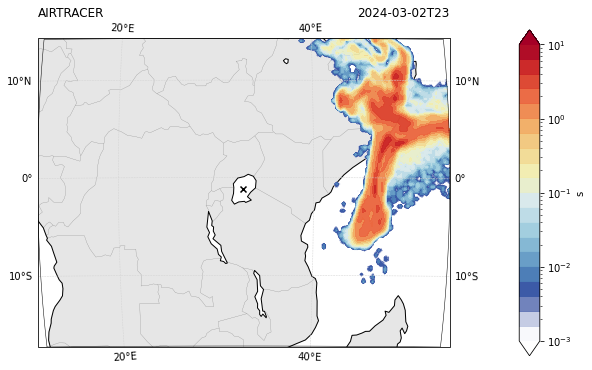

In [4]:
# time step
timestep = 120

# plot map
fig = plot_map(ds.isel(time=[timestep]), cmap, levels, norm)

**Notes on the result**: The unit "s" refers to the average time particles spend in each grid cell at the given time step in seconds. The area-integrated value corresponds to FLEXPART's output time step.

## 1.3) Plot animation of the plume
We can also plot an animation over multiple time steps. You can adapt the timesteps below. If you want to plot all timesteps you can set `timesteps = slice(None)`. This may take some time.

In [ ]:
# time steps
timesteps = slice(90, 120)

# plot animation
ani = plot_map_anim(ds.isel(time=timesteps), cmap, levels, norm)
HTML(ani.to_jshtml())

Instead of looking at moisture using the air tracer, we could do the same for aerosols. Currently only a generic "aerosol" species is available in FLEXWEB (more options will be added in the future). This is what we are going to use in the second exercise.